<a href="https://colab.research.google.com/github/iweam/genai-bootcamp/blob/main/W3S1_Lab_Captioning_and_VQA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#16304A 0%,#003C9C 100%);border-radius:14px;padding:22px 26px;color:#fff;font-family:Segoe UI,Arial,sans-serif;">
  <div style="display:flex;justify-content:space-between;align-items:center;gap:16px;">
    <div>
      <div style="font-size:13px;letter-spacing:1px;opacity:.85;text-transform:uppercase;">Generative AI Summer Bootcamp &middot; Najran University</div>
      <div style="font-size:26px;font-weight:800;margin-top:4px;">Lab — Image Captioning, VQA & CLIP</div>
      <div style="font-size:15px;opacity:.92;margin-top:4px;">Week 3 · Session 1 — Multimodal Foundations</div>
    </div>
    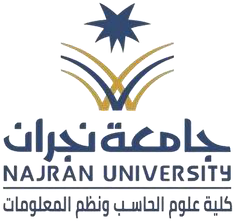
  </div>
  <div style="margin-top:16px;display:flex;gap:10px;flex-wrap:wrap;font-size:13px;">
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">🏆 NCA-GENM track</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">⏱️ Lab: ≈ 47 minutes</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">▶️ Runs on Google Colab (free)</span>
  </div>
</div>

<a target="_blank" href="https://colab.research.google.com/"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:16px;margin-bottom:6px;">🎓 Learning objectives</div>
<ul style="margin:0;padding-left:20px;font-size:15px;color:#16304A;"><li style="margin:5px 0;">Load an image from a URL and <b>caption</b> it with BLIP.</li>
<li style="margin:5px 0;">Ask questions about an image with <b>BLIP visual question answering</b>.</li>
<li style="margin:5px 0;">Run a <b>CLIP zero-shot</b> image classifier against your own labels.</li>
<li style="margin:5px 0;">See how images and text share <b>one embedding space</b>.</li></ul></div>

## How to use this notebook

Run the cells **in order**, top to bottom (`Shift+Enter`). Read the short notes before each part — they connect the code back to today's slides. Every model here is **open and ungated**: no Hugging Face token, API key or login is required.

<div style="border:1px solid #16304A33;border-left:6px solid #16304A;background:#EDF1F6;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#16304A;font-size:15px;margin-bottom:4px;">🔧 First: turn on the free GPU</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Click <b>Runtime → Change runtime type → T4 GPU → Save</b>. The models load faster on the GPU, but everything also runs on CPU (just slower).</div></div>

### Setup
Colab already includes PyTorch, Transformers and Pillow. We just make sure Transformers is recent (BLIP and CLIP need a modern version).

In [1]:
# One-time setup (takes ~20 seconds)
!pip -q install -U "transformers>=4.44" "Pillow>=10.1.0"
print("Setup complete — now run the cells below in order.")

Setup complete — now run the cells below in order.


In [2]:
import torch
from PIL import Image
import requests

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
if DEVICE == "cpu":
    print("Tip: switch to a T4 GPU (see the setup box) for faster runs.")

Using device: cuda


### Load a test image from the web

We'll fetch one image and reuse it for captioning and VQA. This is a free, openly-licensed photo bundled with the Hugging Face examples.

Image size (w, h): (1200, 1600)


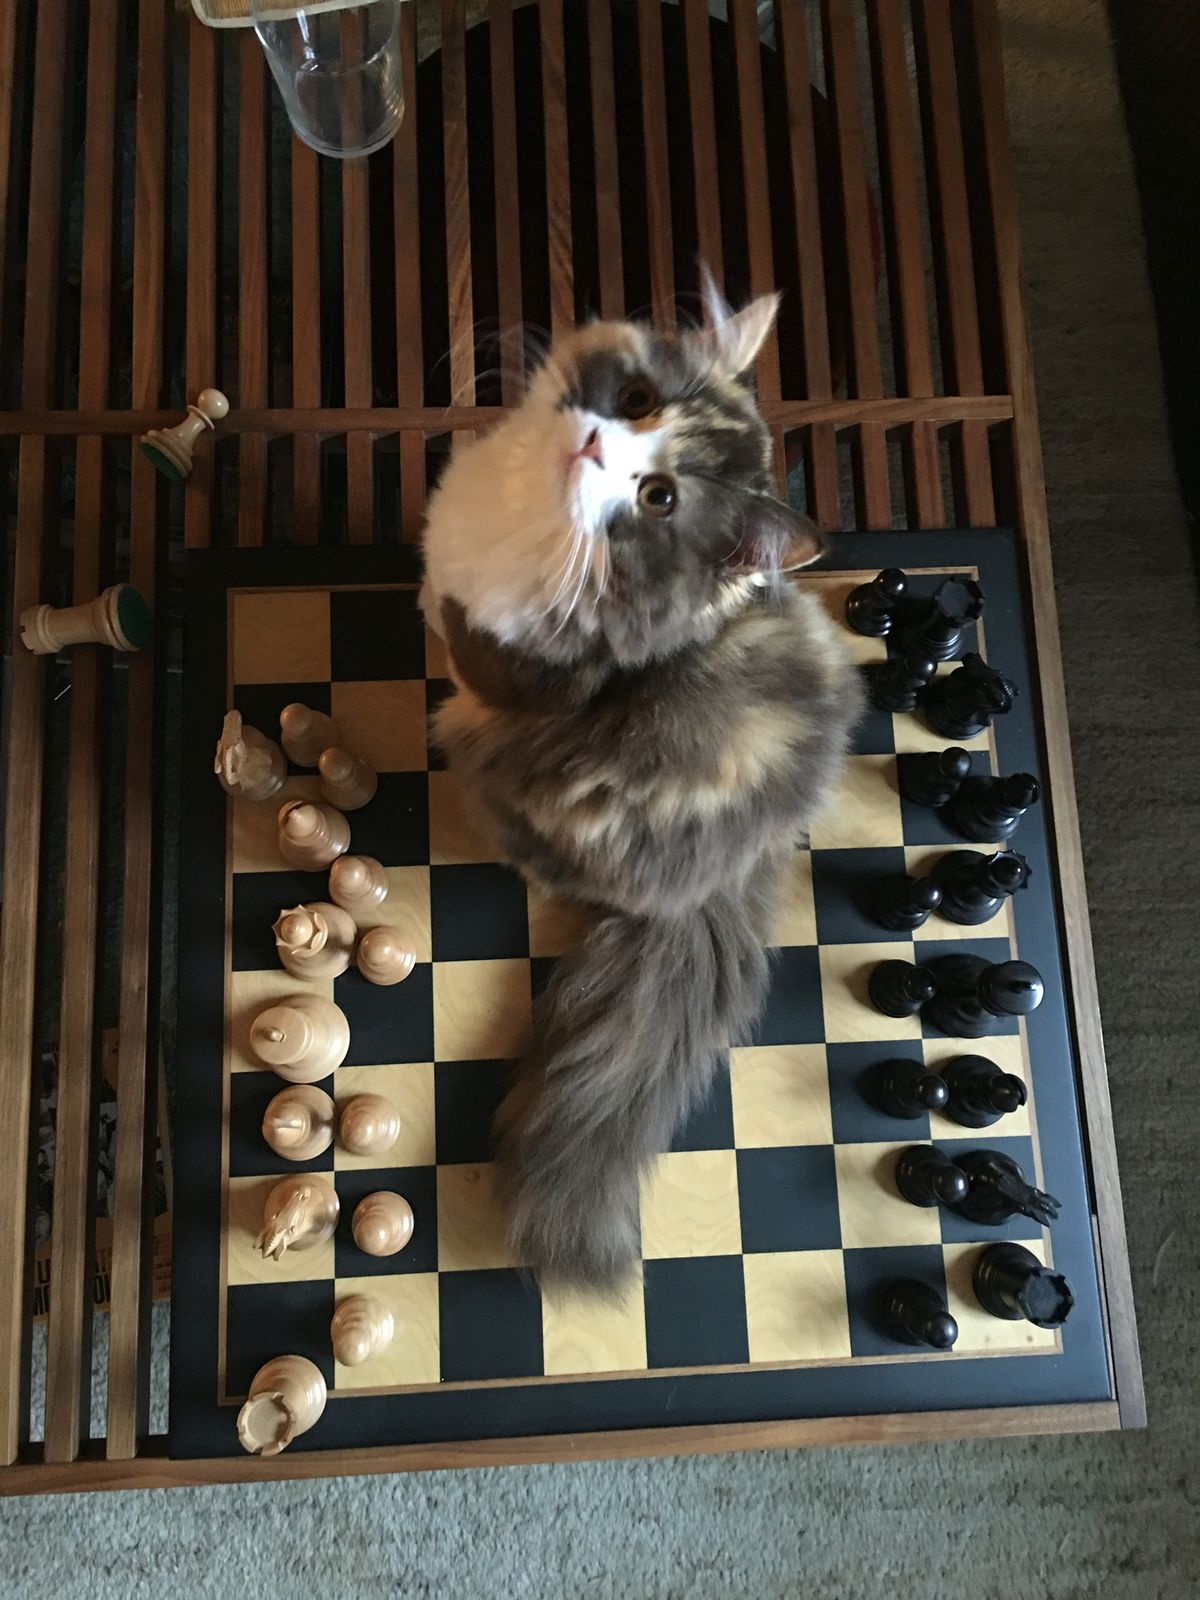

In [3]:
IMG_URL = "https://i.pinimg.com/1200x/33/38/d6/3338d636b1444944635df12ec36aebb0.jpg"
image = Image.open(requests.get(IMG_URL, stream=True).raw).convert("RGB")

print("Image size (w, h):", image.size)
image   # Colab renders the PIL image inline

<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:15px;margin-bottom:4px;">💡 Use your own image</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Replace <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">IMG_URL</code> with any public image URL (must end in .jpg/.png). Re-run this cell, then the cells below will use your image.</div></div>

## Part 1 — Image Captioning with BLIP

**Captioning** takes an image and *generates a description* of it. We use `Salesforce/blip-image-captioning-base` — a vision-language model that fits easily on a T4.

In [4]:
from transformers import BlipProcessor, BlipForConditionalGeneration

CAP_ID = "Salesforce/blip-image-captioning-base"
caption_processor = BlipProcessor.from_pretrained(CAP_ID)
caption_model = BlipForConditionalGeneration.from_pretrained(CAP_ID).to(DEVICE)
print("BLIP captioning model loaded on:", DEVICE)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BLIP captioning model loaded on: cuda


### Generate a caption
The processor turns the image into pixel tensors; the model generates caption tokens; the processor decodes them back into text.

In [5]:
inputs = caption_processor(image, return_tensors="pt").to(DEVICE)
out = caption_model.generate(**inputs, max_new_tokens=30)
caption = caption_processor.decode(out[0], skip_special_tokens=True)

print("Caption:", caption)

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Caption: a cat playing chess with a bunch of onions


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ Conditional captioning</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">You can *steer* the caption by giving BLIP a starting phrase. Pass <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">text="a photo of"</code> to the processor and the model continues from there.</div></div>

In [6]:
# Optional: guide the caption with a prompt prefix
prompt = "a photo of"
inputs = caption_processor(image, text=prompt, return_tensors="pt").to(DEVICE)
out = caption_model.generate(**inputs, max_new_tokens=30)
print("Guided caption:", caption_processor.decode(out[0], skip_special_tokens=True))

Guided caption: a photo of a cat playing chess


<div style="border:1px solid #0C607833;border-left:6px solid #0C6078;background:#E4F1F0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#0C6078;font-size:15px;margin-bottom:4px;">🎯 Exam tip — NCA-GENM</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Captioning is <b>image-to-text generation</b>, part of the <b>Multimodal Data</b> domain. Know the flow: image → image encoder → language decoder → text.</div></div>

## Part 2 — Visual Question Answering (VQA)

**VQA** takes an image **and a question** and returns an answer. We use `Salesforce/blip-vqa-base` — same family, tuned for answering questions.

In [7]:
from transformers import BlipForQuestionAnswering

VQA_ID = "Salesforce/blip-vqa-base"
vqa_processor = BlipProcessor.from_pretrained(VQA_ID)
vqa_model = BlipForQuestionAnswering.from_pretrained(VQA_ID).to(DEVICE)
print("BLIP VQA model loaded on:", DEVICE)

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

BLIP VQA model loaded on: cuda


In [8]:
def ask(question, max_new_tokens=20):
    inputs = vqa_processor(image, question, return_tensors="pt").to(DEVICE)
    out = vqa_model.generate(**inputs, max_new_tokens=max_new_tokens)
    return vqa_processor.decode(out[0], skip_special_tokens=True)

for q in ["What animal is in the image?",
          "What is the cat sitting on?",
          "Is there a chessboard in the image?"]:
    print(f"Q: {q}\nA: {ask(q)}\n")

Q: What animal is in the image?
A: cat

Q: What is the cat sitting on?
A: chess board

Q: Is there a chessboard in the image?
A: yes



<div style="border:1px solid #C2670D33;border-left:6px solid #C2670D;background:#FCEFE0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#C2670D;font-size:15px;margin-bottom:4px;">⚠️ VQA answers are short</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">BLIP-VQA returns concise answers (often one or two words). It can also be wrong, especially on counting and fine detail — a good reminder to verify model outputs.</div></div>

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Your turn — caption & question an image</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Pick <b>your own</b> image URL, caption it, then ask it two questions.</div></div>

In [9]:
# 1) Load your own image (use a public .jpg/.png URL)
MY_URL = "https://i.pinimg.com/1200x/33/38/d6/3338d636b1444944635df12ec36aebb0.jpg"  # <- change me
my_image = Image.open(requests.get(MY_URL, stream=True).raw).convert("RGB")

# 2) Caption it
inp = caption_processor(my_image, return_tensors="pt").to(DEVICE)
cap = caption_processor.decode(caption_model.generate(**inp, max_new_tokens=30)[0],
                               skip_special_tokens=True)
print("Caption:", cap)

# 3) Ask it a question (reuse the ask() helper, but on my_image)
q = "What is in the picture?"
inp = vqa_processor(my_image, q, return_tensors="pt").to(DEVICE)
print("Q:", q, "\nA:", vqa_processor.decode(
    vqa_model.generate(**inp, max_new_tokens=20)[0], skip_special_tokens=True))

Caption: a cat playing chess with a bunch of onions
Q: What is in the picture? 
A: cat


## Part 3 — CLIP Zero-Shot Classification

**CLIP** puts images and text in **one shared space**. To classify an image we just write candidate labels as text, embed everything, and pick the closest label — **no training** on these classes.

In [10]:
from transformers import CLIPProcessor, CLIPModel

CLIP_ID = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(CLIP_ID).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(CLIP_ID)
print("CLIP model loaded on:", DEVICE)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded on: cuda


### Classify the image against labels we invent on the spot
CLIP works best when labels are written as short phrases, e.g. *“a photo of a cat”*.

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ What just happened</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">CLIP encoded the <b>image</b> and each <b>label</b> into the same space, measured similarity, and turned the scores into probabilities with softmax. The labels were never seen in training as classes — that is <b>zero-shot</b> classification.</div></div>

<div style="border:1px solid #0C607833;border-left:6px solid #0C6078;background:#E4F1F0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#0C6078;font-size:15px;margin-bottom:4px;">🎯 Exam tip — NCA-GENM</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">CLIP + zero-shot classification spans <b>Core ML & AI</b> and <b>Multimodal Data</b>. Remember: contrastive training aligns image and text embeddings in <b>one shared space</b>, which is what makes zero-shot transfer possible.</div></div>

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Your turn — design your own labels</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Change the candidate labels and see how CLIP responds. Try adding a clearly wrong label and a very specific correct one — does the right one still win?</div></div>

In [12]:
# Edit these labels, then run
my_labels = [ "a photo of a cat",
    "a photo of a chessboard",
    "a fluffy gray and white cat",
    "a cat sitting on a chessboard"
    ]

inputs = clip_processor(text=my_labels, images=image,
                        return_tensors="pt", padding=True).to(DEVICE)
with torch.no_grad():
    probs = clip_model(**inputs).logits_per_image.softmax(dim=1)[0]

for label, p in sorted(zip(my_labels, probs.tolist()), key=lambda x: -x[1]):
    print(f"{p*100:5.1f}%  {label}")

100.0%  a cat sitting on a chessboard
  0.0%  a photo of a chessboard
  0.0%  a photo of a cat
  0.0%  a fluffy gray and white cat


<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:16px;margin-bottom:6px;">✅ Recap &amp; exam-readiness check</div>
<ul style="margin:0;padding-left:20px;font-size:15px;"><li style="margin:5px 0;"><b>Multimodal</b> models handle images, audio and text together.</li>
<li style="margin:5px 0;">A <b>shared embedding space</b> makes images and text directly comparable.</li>
<li style="margin:5px 0;"><b>BLIP</b> does image-to-text: <b>captioning</b> (describe) and <b>VQA</b> (answer a question).</li>
<li style="margin:5px 0;"><b>CLIP</b> aligns image & text via contrastive training → <b>zero-shot</b> classification with no labelled data.</li>
<li style="margin:5px 0;">All of this runs on a <b>free Colab T4</b> with open, ungated models — no token needed.</li></ul></div>

---
### Save your work
Commit this notebook to your **`genai-bootcamp-lab1`** GitHub repo from the Week-1 setup lab (`File → Save a copy in GitHub`). Next session: audio with Whisper and text-to-image generation.